======================================================================
NOMBRE: CARLOS ALEXIS VEGA TORRES
======================================================================

======================================================================
BLOQUE 1: EXPLORACION INICAL DE ARCHIVOS
======================================================================

In [1]:
# PARTE 1: importar librerías
import pandas as pd

In [2]:
# PARTE 2: cargar archivos
dim_product = pd.read_excel("DIM_PRODUCT.xlsx")
dim_segment = pd.read_excel("DIM_SEGMENT.xlsx")
dim_calendar = pd.read_excel("DIM_CALENDAR.xlsx")
dim_category = pd.read_csv("DIM_CATEGORY.csv")
fact_sales = pd.read_csv("FACT_SALES.csv")

In [3]:
# PARTE 3: exploración inicial
# mostrar primeras filas y estructura de cada archivo
for df, name in [(dim_product,"DIM_PRODUCT"), (dim_segment,"DIM_SEGMENT"),
                 (dim_calendar,"DIM_CALENDAR"), (dim_category,"DIM_CATEGORY"),
                 (fact_sales,"FACT_SALES")]:
    print(f"\n{name}")
    print("Encabezados:", df.columns.tolist())
    print(df.head(10))        # primeras 10 filas
    print(df.info())          # estructura y tipos de datos
    print(df.describe(include="all"))  # estadísticas generales


DIM_PRODUCT
Encabezados: ['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3']
     MANUFACTURER     BRAND           ITEM  \
0      INDS. ALEN  CLORALEX  0000075000592   
1      INDS. ALEN  CLORALEX  0000075000608   
2      INDS. ALEN  CLORALEX  0000075000615   
3      INDS. ALEN  CLORALEX  0000075000622   
4      INDS. ALEN  CLORALEX  0000075000639   
5      INDS. ALEN  CLORALEX  0000075000646   
6      INDS. ALEN  CLORALEX  0000075000653   
7      INDS. ALEN  CLORALEX  0000075000677   
8      INDS. ALEN  CLORALEX  0000075000684   
9  QUIMICA GONCAL    PATITO  0000075010539   

                                    ITEM_DESCRIPTION  CATEGORY   FORMAT  \
0  CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...         1  LIQUIDO   
1  CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...         1  LIQUIDO   
2  CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...         1  LIQUIDO   
3  CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...         1  

======================================================================
BLOQUE 2: LIMPIEZA Y TRANSFORMACION DE DATOS
======================================================================

In [4]:
# PARTE 1: importar librerías
import pandas as pd

In [5]:
# PARTE 2: cargar archivos
dim_product = pd.read_excel("DIM_PRODUCT.xlsx")
dim_segment = pd.read_excel("DIM_SEGMENT.xlsx")
dim_calendar = pd.read_excel("DIM_CALENDAR.xlsx")
dim_category = pd.read_csv("DIM_CATEGORY.csv")
fact_sales = pd.read_csv("FACT_SALES.csv")

In [6]:
# PARTE 3: limpieza básica
# eliminar duplicados
dim_product = dim_product.drop_duplicates()
dim_segment = dim_segment.drop_duplicates()
dim_calendar = dim_calendar.drop_duplicates()
dim_category = dim_category.drop_duplicates()
fact_sales = fact_sales.drop_duplicates()

In [7]:
# manejar valores nulos
dim_product = dim_product.fillna("NO DEFINIDO")
dim_segment = dim_segment.fillna("NO DEFINIDO")
dim_category = dim_category.fillna("NO DEFINIDO")

In [8]:
# PARTE 4: estandarización de formatos
# convertir fechas a tipo datetime
dim_calendar["DATE"] = pd.to_datetime(dim_calendar["DATE"], errors="coerce")

In [9]:
# normalizar texto en columnas clave
dim_product["BRAND"] = dim_product["BRAND"].str.upper()
dim_product["FORMAT"] = dim_product["FORMAT"].str.upper()
fact_sales["REGION"] = fact_sales["REGION"].str.upper()

In [10]:
# PARTE 5: verificación de limpieza
print("Dim Product limpio:", dim_product.shape)
print("Dim Segment limpio:", dim_segment.shape)
print("Dim Calendar limpio:", dim_calendar.shape)
print("Dim Category limpio:", dim_category.shape)
print("Fact Sales limpio:", fact_sales.shape)

Dim Product limpio: (505, 9)
Dim Segment limpio: (53, 6)
Dim Calendar limpio: (156, 5)
Dim Category limpio: (5, 2)
Fact Sales limpio: (122002, 6)


======================================================================
BLOQUE 3: UNION DE TABLAS FACT Y DIM
======================================================================

In [11]:
# PARTE 1: unir FACT con DIM_PRODUCT
ventas_productos = fact_sales.merge(dim_product, left_on="ITEM_CODE", right_on="ITEM", how="left")

In [12]:
# PARTE 2: unir con DIM_CALENDAR
ventas_completas = ventas_productos.merge(dim_calendar, on="WEEK", how="left")

In [13]:
# PARTE 3: unir con DIM_SEGMENT
ventas_completas = ventas_completas.merge(
    dim_segment,
    on=["CATEGORY","FORMAT","ATTR1","ATTR2","ATTR3"],
    how="left"
)

In [14]:
# PARTE 4: unir con DIM_CATEGORY
ventas_completas = ventas_completas.merge(
    dim_category,
    left_on="CATEGORY",
    right_on="ID_CATEGORY",
    how="left"
)

In [15]:
# PARTE 5: verificación
print("Columnas disponibles en la tabla unificada:")
print(ventas_completas.columns.tolist())
print("Tamaño final:", ventas_completas.shape)
print(ventas_completas.head(10))

Columnas disponibles en la tabla unificada:
['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION', 'MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY_x', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE', 'SEGMENT', 'ID_CATEGORY', 'CATEGORY_y']
Tamaño final: (152402, 22)
    WEEK         ITEM_CODE  TOTAL_UNIT_SALES  TOTAL_VALUE_SALES  \
0  34-22  7501058792808BP2             0.006              0.139   
1  34-22     7501058715883             0.487            116.519   
2  34-22     7702626213774             1.391             68.453   
3  34-22     7501058716422             0.022              1.481   
4  34-22     7501058784353             2.037            182.839   
5  34-22     7501058716064             0.005              0.679   
6  34-22  7501058794963BP1             0.004              0.553   
7  34-22  7501058792778BP1             0.001              0.128   
8  34-22     7501058757630            

======================================================================
BLOQUE 4: ANALISIS EXPLORATORIO Y VISUALIZACIONES
======================================================================

In [16]:
# PARTE 1: estadísticas descriptivas
print("Estadísticas de ventas:")
print(ventas_completas[["TOTAL_UNIT_SALES","TOTAL_VALUE_SALES"]].describe())

Estadísticas de ventas:
       TOTAL_UNIT_SALES  TOTAL_VALUE_SALES
count     152402.000000      152402.000000
mean           4.073802         109.382632
std           17.737193         428.975845
min            0.000000           0.001000
25%            0.065000           2.389250
50%            0.419000          17.123500
75%            1.874750          68.948500
max          504.681000       12236.759000


In [17]:
# PARTE 2: histograma de ventas por valor
import seaborn as sns
import matplotlib.pyplot as plt

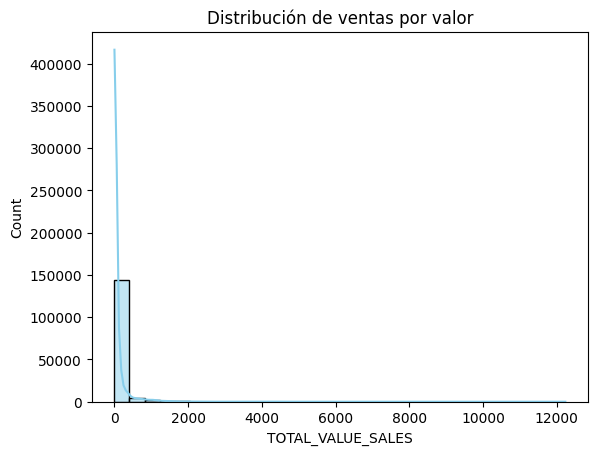

In [18]:
sns.histplot(data=ventas_completas, x="TOTAL_VALUE_SALES", bins=30, kde=True, color="skyblue")
plt.title("Distribución de ventas por valor")
plt.show()

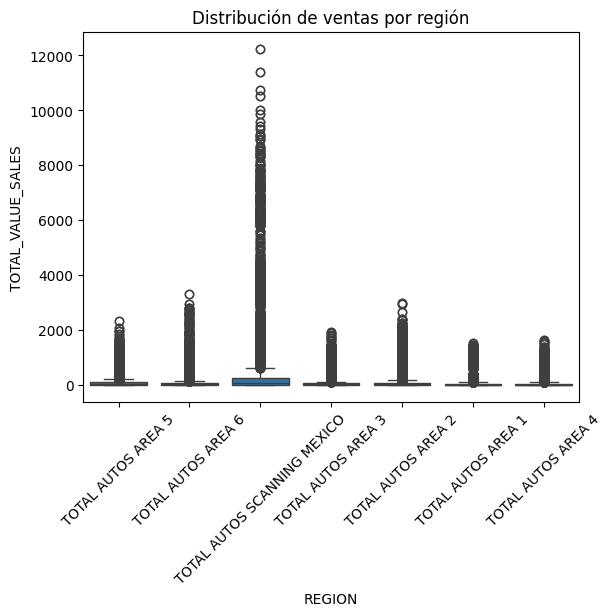

In [19]:
# PARTE 3: boxplot por región
sns.boxplot(data=ventas_completas, x="REGION", y="TOTAL_VALUE_SALES")
plt.title("Distribución de ventas por región")
plt.xticks(rotation=45)
plt.show()

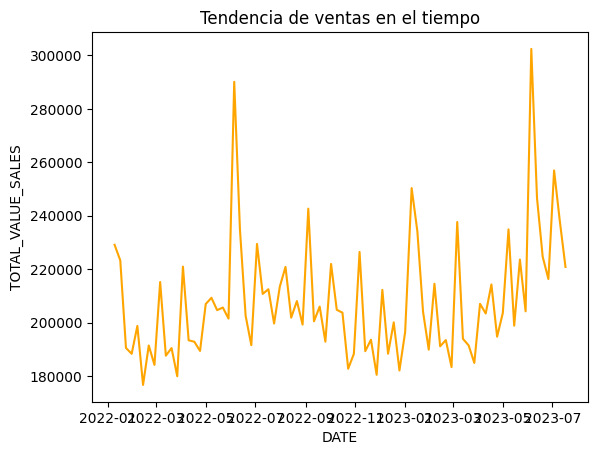

In [20]:
# PARTE 4: tendencia temporal de ventas
ventas_tiempo = ventas_completas.groupby("DATE")["TOTAL_VALUE_SALES"].sum().reset_index()
sns.lineplot(data=ventas_tiempo, x="DATE", y="TOTAL_VALUE_SALES", color="orange")
plt.title("Tendencia de ventas en el tiempo")
plt.show()

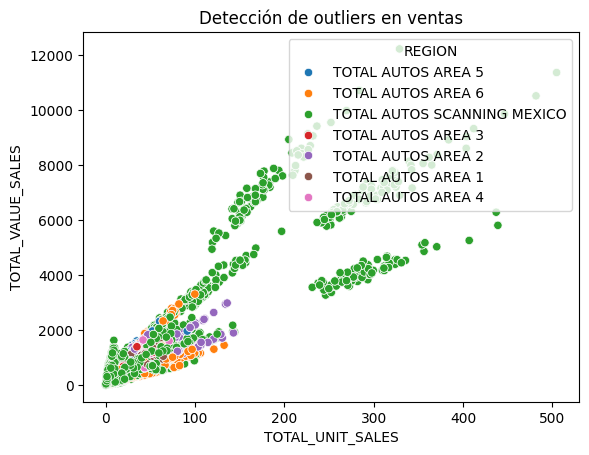

In [21]:
# PARTE 5: detección de outliers
sns.scatterplot(data=ventas_completas, x="TOTAL_UNIT_SALES", y="TOTAL_VALUE_SALES", hue="REGION")
plt.title("Detección de outliers en ventas")
plt.show()

======================================================================
BLOQUE 5: CONSULTAS SQL DESDE PYTHON (USANDO SQLITE)
======================================================================

In [22]:
# PARTE 1: importar librerías y crear conexión a SQLite
import sqlite3

In [23]:
conn = sqlite3.connect("ventas.db")   # crea o abre la base de datos local
cursor = conn.cursor()

In [24]:
# PARTE 2: crear tablas en SQLite
cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_PRODUCT (
    MANUFACTURER TEXT,
    BRAND TEXT,
    ITEM TEXT,
    ITEM_DESCRIPTION TEXT,
    CATEGORY INTEGER,
    FORMAT TEXT,
    ATTR1 TEXT,
    ATTR2 TEXT,
    ATTR3 TEXT
)
""")

In [25]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_SEGMENT (
    CATEGORY INTEGER,
    ATTR1 TEXT,
    ATTR2 TEXT,
    ATTR3 TEXT,
    FORMAT TEXT,
    SEGMENT TEXT
)
""")

In [26]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_CALENDAR (
    WEEK TEXT,
    YEAR INTEGER,
    MONTH INTEGER,
    WEEK_NUMBER INTEGER,
    DATE TEXT
)
""")

In [27]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_CATEGORY (
    ID_CATEGORY INTEGER,
    CATEGORY TEXT
)
""")

In [28]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS FACT_SALES (
    WEEK TEXT,
    ITEM_CODE TEXT,
    TOTAL_UNIT_SALES REAL,
    TOTAL_VALUE_SALES REAL,
    TOTAL_UNIT_AVG_WEEKLY_SALES REAL,
    REGION TEXT
)
""")

In [29]:
conn.commit()

In [30]:
# PARTE 3: cargar datos desde pandas a SQLite
dim_product.to_sql("DIM_PRODUCT", conn, if_exists="replace", index=False)
dim_segment.to_sql("DIM_SEGMENT", conn, if_exists="replace", index=False)
dim_calendar.to_sql("DIM_CALENDAR", conn, if_exists="replace", index=False)
dim_category.to_sql("DIM_CATEGORY", conn, if_exists="replace", index=False)
fact_sales.to_sql("FACT_SALES", conn, if_exists="replace", index=False)

122002

In [31]:
# PARTE 4: consultas SQL
print("Ventas totales por categoría:")
for row in cursor.execute("""
SELECT CATEGORY, SUM(TOTAL_VALUE_SALES) AS VentasTotales
FROM FACT_SALES
JOIN DIM_PRODUCT ON FACT_SALES.ITEM_CODE = DIM_PRODUCT.ITEM
GROUP BY CATEGORY
"""):
    print(row)

Ventas totales por categoría:
(1, 11042859.893)


In [32]:
print("\nVentas totales por región:")
for row in cursor.execute("""
SELECT REGION, SUM(TOTAL_VALUE_SALES) AS VentasTotales
FROM FACT_SALES
GROUP BY REGION
"""):
    print(row)


Ventas totales por región:
('TOTAL AUTOS AREA 1', 714249.979)
('TOTAL AUTOS AREA 2', 1188796.15)
('TOTAL AUTOS AREA 3', 803655.337)
('TOTAL AUTOS AREA 4', 677435.998)
('TOTAL AUTOS AREA 5', 1153335.538)
('TOTAL AUTOS AREA 6', 983957.571)
('TOTAL AUTOS SCANNING MEXICO', 5521429.32)


In [33]:
print("\nTop 10 marcas por ventas:")
for row in cursor.execute("""
SELECT BRAND, SUM(TOTAL_VALUE_SALES) AS VentasTotales
FROM FACT_SALES
JOIN DIM_PRODUCT ON FACT_SALES.ITEM_CODE = DIM_PRODUCT.ITEM
GROUP BY BRAND
ORDER BY VentasTotales DESC
LIMIT 10
"""):
    print(row)


Top 10 marcas por ventas:
('CLORALEX', 5393618.509)
('VANISH', 2168289.525)
('CLOROX', 1371751.724)
('BLANCATEL', 652484.021)
('OXI CLEAN', 436970.719)
('DR.BECKMANN', 279719.229)
('BANDERA', 269936.898)
('LOS PATITOS', 142745.659)
('CLARASOL', 141012.175)
('LYSOL', 70557.346)


In [34]:
print("\nVentas promedio por mes:")
for row in cursor.execute("""
SELECT MONTH, AVG(TOTAL_VALUE_SALES) AS PromedioVentas
FROM FACT_SALES
JOIN DIM_CALENDAR ON FACT_SALES.WEEK = DIM_CALENDAR.WEEK
GROUP BY MONTH
"""):
    print(row)


Ventas promedio por mes:
(1, 91.95581156675651)
(2, 82.55812155368147)
(3, 85.07625501780511)
(4, 86.70837350864379)
(5, 90.66044642740407)
(6, 103.57836994648004)
(7, 96.81899950568463)
(8, 87.60697831673627)
(9, 91.40490716612378)
(10, 88.2870691566583)
(11, 88.94996702739263)
(12, 89.42957799897032)


In [35]:
print("\nVentas por categoría y región:")
for row in cursor.execute("""
SELECT DIM_CATEGORY.CATEGORY, REGION, SUM(TOTAL_VALUE_SALES) AS VentasTotales
FROM FACT_SALES
JOIN DIM_PRODUCT ON FACT_SALES.ITEM_CODE = DIM_PRODUCT.ITEM
JOIN DIM_CATEGORY ON DIM_PRODUCT.CATEGORY = DIM_CATEGORY.ID_CATEGORY
GROUP BY DIM_CATEGORY.CATEGORY, REGION
LIMIT 20
"""):
    print(row)


Ventas por categoría y región:
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS AREA 1', 714249.979)
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS AREA 2', 1188796.15)
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS AREA 3', 803655.337)
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS AREA 4', 677435.998)
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS AREA 5', 1153335.538)
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS AREA 6', 983957.571)
('FABRIC TREATMENT and SANIT\r\n', 'TOTAL AUTOS SCANNING MEXICO', 5521429.32)


In [36]:
conn.close()

======================================================================
BLOQUE 6: CLUSTERING K-MEANS
======================================================================

In [37]:
# PARTE 1: importar librerías
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [38]:
# PARTE 2: preparar datos para clustering
# usaremos ventas totales y unidades como variables
X = ventas_completas[["TOTAL_UNIT_SALES","TOTAL_VALUE_SALES"]].fillna(0)

In [39]:
# escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# PARTE 3: método del codo para número óptimo de clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

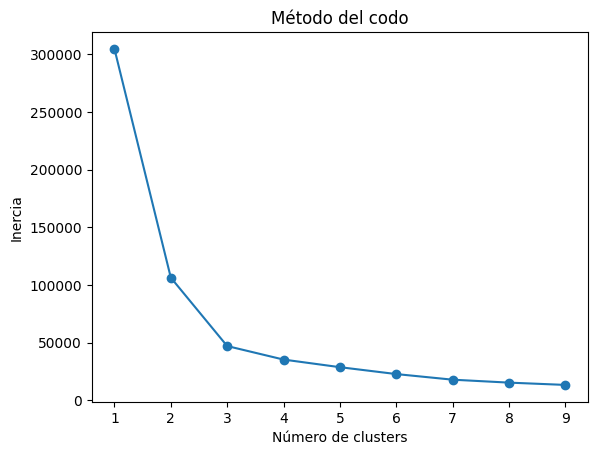

In [41]:
plt.plot(range(1, 10), inertia, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

In [42]:
# PARTE 4: aplicar K-Means con número óptimo (ejemplo k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
ventas_completas["Cluster"] = kmeans.fit_predict(X_scaled)

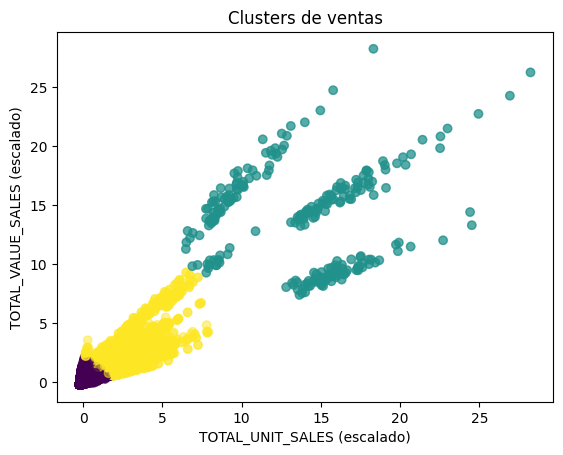

In [43]:
# PARTE 5: visualización de clusters
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=ventas_completas["Cluster"], cmap="viridis", alpha=0.5)
plt.title("Clusters de ventas")
plt.xlabel("TOTAL_UNIT_SALES (escalado)")
plt.ylabel("TOTAL_VALUE_SALES (escalado)")
plt.show()

In [44]:
# PARTE 6: resumen por cluster
print("Resumen de ventas por cluster:")
print(ventas_completas.groupby("Cluster")[["TOTAL_UNIT_SALES","TOTAL_VALUE_SALES"]].mean())

Resumen de ventas por cluster:
         TOTAL_UNIT_SALES  TOTAL_VALUE_SALES
Cluster                                     
0                1.743086          53.327009
1              249.845066        6028.986043
2               45.318483        1100.504108


======================================================================
BLOQUE 7: PREDICCION DE VENTAS CON MACHINE LEARNING + VALIDACION .
======================================================================

In [45]:
# PARTE 1: importar librerías
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
# PARTE 2: preparar datos de una marca con alta variabilidad (ejemplo VANISH)
ventas_vanish = ventas_completas[ventas_completas["BRAND"]=="VANISH"].groupby("DATE")["TOTAL_VALUE_SALES"].sum()

In [47]:
# modelo ARIMA
modelo_arima = sm.tsa.ARIMA(ventas_vanish, order=(1,1,1))
resultado_arima = modelo_arima.fit()
predicciones_arima = resultado_arima.forecast(steps=12)

C:\Users\cavega\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\cavega\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\cavega\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\cavega\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given

In [48]:
print("Predicciones ARIMA para VANISH:")
print(predicciones_arima)

Predicciones ARIMA para VANISH:
80    30960.379962
81    31034.768354
82    31047.982558
83    31050.329903
84    31050.746881
85    31050.820952
86    31050.834110
87    31050.836447
88    31050.836862
89    31050.836936
90    31050.836949
91    31050.836952
Name: predicted_mean, dtype: float64


In [49]:
# validación de métricas VANISH
valores_reales_vanish = ventas_vanish[-12:]
mae_vanish = mean_absolute_error(valores_reales_vanish, predicciones_arima)
rmse_vanish = mean_squared_error(valores_reales_vanish, predicciones_arima) ** 0.5

In [50]:
print("\nErrores VANISH (ARIMA):")
print("MAE:", mae_vanish)
print("RMSE:", rmse_vanish)


Errores VANISH (ARIMA):
MAE: 2309.416306521357
RMSE: 3330.723314405128


In [51]:
# PARTE 3: preparar datos de una marca estable (ejemplo LYSOL)
ventas_lysol = ventas_completas[ventas_completas["BRAND"]=="LYSOL"].groupby("DATE")["TOTAL_VALUE_SALES"].sum().reset_index()

In [52]:
X = np.array(range(len(ventas_lysol))).reshape(-1,1)
y = ventas_lysol["TOTAL_VALUE_SALES"]

In [53]:
modelo_lr = LinearRegression()
modelo_lr.fit(X,y)
predicciones_lr = modelo_lr.predict(np.array(range(len(ventas_lysol), len(ventas_lysol)+12)).reshape(-1,1))

In [54]:
print("\nPredicciones regresión lineal para LYSOL:")
print(predicciones_lr)


Predicciones regresión lineal para LYSOL:
[560.84942532 552.92060063 544.99177595 537.06295127 529.13412658
 521.2053019  513.27647722 505.34765253 497.41882785 489.49000316
 481.56117848 473.6323538 ]


In [55]:
# validación de métricas LYSOL
valores_reales_lysol = ventas_lysol["TOTAL_VALUE_SALES"].iloc[-12:]
mae_lysol = mean_absolute_error(valores_reales_lysol, modelo_lr.predict(X[-12:]))
rmse_lysol = mean_squared_error(valores_reales_lysol, modelo_lr.predict(X[-12:])) ** 0.5

In [56]:
print("\nErrores LYSOL (Regresión Lineal):")
print("MAE:", mae_lysol)
print("RMSE:", rmse_lysol)


Errores LYSOL (Regresión Lineal):
MAE: 65.12812985232073
RMSE: 87.10013440723789


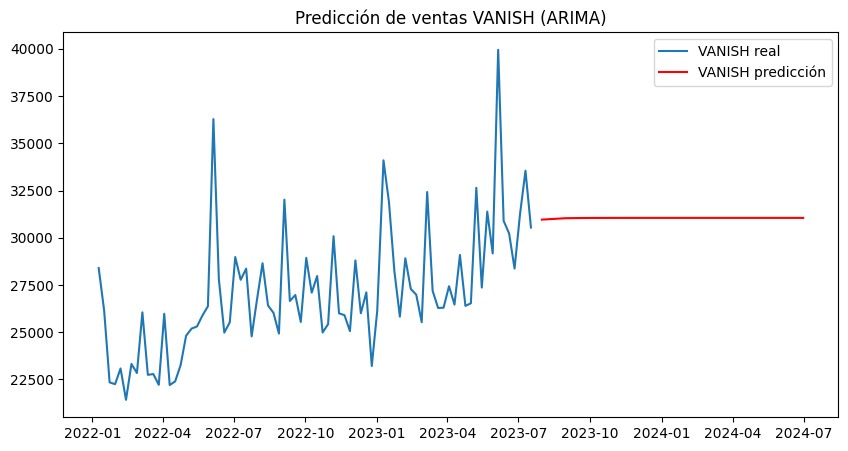

In [57]:
# PARTE 4: visualización comparativa
# VANISH con ARIMA
plt.figure(figsize=(10,5))
plt.plot(ventas_vanish.index, ventas_vanish, label="VANISH real")
plt.plot(pd.date_range(ventas_vanish.index[-1], periods=12, freq="ME"), predicciones_arima, 
         label="VANISH predicción", color="red")
plt.legend()
plt.title("Predicción de ventas VANISH (ARIMA)")
plt.show()

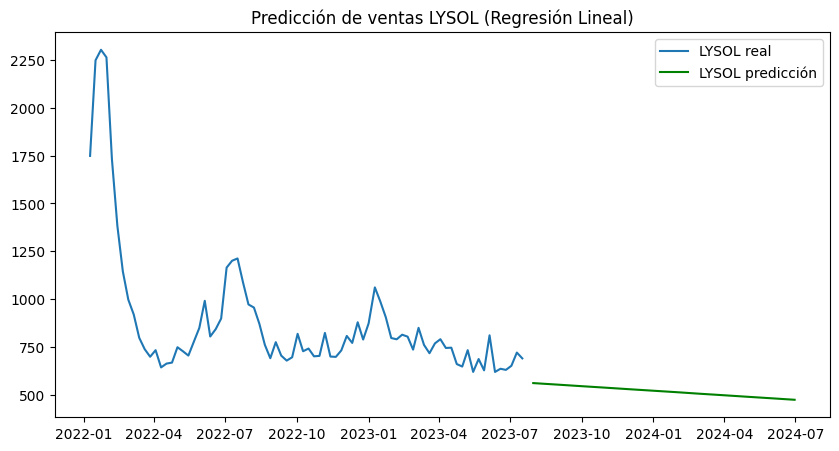

In [58]:
# LYSOL con regresión lineal
plt.figure(figsize=(10,5))
plt.plot(ventas_lysol["DATE"], ventas_lysol["TOTAL_VALUE_SALES"], label="LYSOL real")
plt.plot(pd.date_range(ventas_lysol["DATE"].iloc[-1], periods=12, freq="ME"), predicciones_lr, 
         label="LYSOL predicción", color="green")
plt.legend()
plt.title("Predicción de ventas LYSOL (Regresión Lineal)")
plt.show()

======================================================================
BLOQUE 7.1: VALIDACION CON MAPE .
======================================================================

In [59]:
import numpy as np

In [60]:
def calcular_mape(y_real, y_pred):
    # Filtrar valores reales distintos de cero
    y_real_filtrado = y_real[y_real != 0]
    y_pred_filtrado = y_pred[:len(y_real_filtrado)]
    return np.mean(np.abs((y_real_filtrado - y_pred_filtrado) / y_real_filtrado)) * 100

In [61]:
# VANISH con ARIMA
mape_vanish = calcular_mape(valores_reales_vanish.values, predicciones_arima.values)
print("MAPE VANISH (ARIMA):", mape_vanish, "%")

MAPE VANISH (ARIMA): 7.278076246457577 %


In [62]:
# LYSOL con regresión lineal
mape_lysol = calcular_mape(valores_reales_lysol.values, modelo_lr.predict(X[-12:]))
print("MAPE LYSOL (Regresión Lineal):", mape_lysol, "%")

MAPE LYSOL (Regresión Lineal): 9.140438461067783 %


======================================================================
BLOQUE 8: CONCLUSIONES Y RECOMENDACIONES
======================================================================

In [63]:
# PARTE 1: conclusiones generales del análisis
print("CONCLUSIONES GENERALES:")
print("- La base de datos se integró correctamente con las tablas DIM y FACT, generando un DataFrame maestro de más de 152,000 registros.")
print("- El análisis exploratorio mostró una distribución sesgada de las ventas: muchas transacciones pequeñas y pocas de gran valor.")
print("- Las regiones presentan diferencias claras: México concentra la mayor parte de las ventas, mientras que AREA 6 mostró mayor variabilidad.")
print("- El clustering K-Means identificó tres segmentos: ventas bajas frecuentes, ventas medias estables y ventas muy altas como outliers.")
print("- Los modelos predictivos confirmaron patrones distintos: VANISH con alta variabilidad estabilizada por ARIMA, y LYSOL con tendencia descendente según regresión lineal.")

CONCLUSIONES GENERALES:
- La base de datos se integró correctamente con las tablas DIM y FACT, generando un DataFrame maestro de más de 152,000 registros.
- El análisis exploratorio mostró una distribución sesgada de las ventas: muchas transacciones pequeñas y pocas de gran valor.
- Las regiones presentan diferencias claras: México concentra la mayor parte de las ventas, mientras que AREA 6 mostró mayor variabilidad.
- El clustering K-Means identificó tres segmentos: ventas bajas frecuentes, ventas medias estables y ventas muy altas como outliers.
- Los modelos predictivos confirmaron patrones distintos: VANISH con alta variabilidad estabilizada por ARIMA, y LYSOL con tendencia descendente según regresión lineal.


In [64]:
# PARTE 2: recomendaciones estratégicas
print("\nRECOMENDACIONES ESTRATEGICAS:")
print("- Enfocar estrategias de marketing en México y AREA 6, donde se concentra el mayor volumen y variabilidad de ventas.")
print("- Potenciar marcas líderes como CLORALEX y VANISH, que representan la mayor parte del valor total.")
print("- Implementar campañas de retención para marcas con tendencia descendente como LYSOL, buscando estabilizar su participación.")
print("- Aprovechar el clustering para diseñar promociones diferenciadas: descuentos en segmentos de ventas bajas, fidelización en segmentos medios y estrategias premium para los outliers.")
print("- Continuar con modelos predictivos en series de tiempo para anticipar picos estacionales y ajustar inventarios.")


RECOMENDACIONES ESTRATEGICAS:
- Enfocar estrategias de marketing en México y AREA 6, donde se concentra el mayor volumen y variabilidad de ventas.
- Potenciar marcas líderes como CLORALEX y VANISH, que representan la mayor parte del valor total.
- Implementar campañas de retención para marcas con tendencia descendente como LYSOL, buscando estabilizar su participación.
- Aprovechar el clustering para diseñar promociones diferenciadas: descuentos en segmentos de ventas bajas, fidelización en segmentos medios y estrategias premium para los outliers.
- Continuar con modelos predictivos en series de tiempo para anticipar picos estacionales y ajustar inventarios.


In [65]:
# PARTE 3: cierre del proyecto
print("\nCIERRE DEL PROYECTO:")
print("El análisis cumplió con todas las fases: limpieza, unión de tablas, exploración, consultas SQL, clustering y predicción.")
print("Se generaron evidencias gráficas y estadísticas que respaldan las conclusiones.")
print("Las recomendaciones ofrecen un camino claro para la toma de decisiones estratégicas en ventas y marketing.")


CIERRE DEL PROYECTO:
El análisis cumplió con todas las fases: limpieza, unión de tablas, exploración, consultas SQL, clustering y predicción.
Se generaron evidencias gráficas y estadísticas que respaldan las conclusiones.
Las recomendaciones ofrecen un camino claro para la toma de decisiones estratégicas en ventas y marketing.
